In [1]:
import sys
import twopoint as tp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker
import pickle as pl
from astropy.io import fits
import yaml
from matplotlib import ticker
import configparser
import fitsio as fio
import os
import pickle
import h5py as h5
import glob
import twopoint as tp
%matplotlib inline

In [35]:
log=False
matplotlib.rcParams["xtick.direction"]='in'
matplotlib.rcParams["ytick.direction"]='in'

def get_axes_(name,i,j,rows,cols,dxi=False):
    if not dxi:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1)),i-1),rowspan=2)
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1),6-i),rowspan=2)
    else:
        if name == 'xip':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(3-(j-1))+2,i-1))
        elif name=='xim':
            ax = plt.subplot2grid(( cols*3,rows+2), (3*(j-1)+2,6-i))
    return ax


def get_angle_range_agg(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']
    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
        #print(name, str(j), str(i), np.array(scales[name].split()).astype(float))
    return np.array(scales[name].split()).astype(float)

def get_angle_range(xi,j,i):
    config = configparser.ConfigParser()
    config.read(scfile)
    scales = config['2pt_like']

    if xi == 'xip':
        name = 'angle_range_xip_'+str(j)+'_'+str(i)
    else:
        name = 'angle_range_xim_'+str(j)+'_'+str(i)
    return np.array(scales[name].split()).astype(float)

def get_params(xi,theta):
    if xi == 'xip' or xi == 'xim':
        #lims = [(-0.5,4.4),(0.,4.4),(0.,4.4),(0.,4.4)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]
        # lims = [(-0.5,4.5),(-0.5,4.5),(-0.5,4.5),(-0.5,4.5)]#[(-0.4,1.2),(-0.4,1.6),(-0.6,3.),(-0.6,4.45)]
        lims = [(-2.5,9.5),(-2.5,9.5),(-2.5,9.5),(-2.5,9.5)]


        dlims = [(-1.5,2.5) for i in range(4)]
        tmult = theta
        dmult = 1e4
        dmult2 = 1e4
        lx = [0.05, 0.93]
    return lims, dlims,tmult,dmult,dmult2,lx

def set_axes(name,ax,dxi=False):
    if not dxi:
        if (name=='xim')&(i==1):
            plt.xlabel(r'$\theta$ [arcmin]')
        else:
            ax.set_xticklabels([])
        if i!=1:
            ax.set_yticklabels([])
        if (i==1)&(j==1):
            if name == 'xip':
                print("123")
                # plt.ylabel(r'$   10^{4}\theta\xi_{+}    $', labelpad=15) 
                plt.ylabel(r'$\theta\xi_{+}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                print(x,y)
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                # plt.ylabel(r'$   10^{4}\theta\xi_{-}     $')
                plt.ylabel(r'$\theta\xi_{-}    $', labelpad=15) 
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")
    else:
        if (name=='xim')&(j==4): #&(j==4):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        elif (name=='xip')&(i==1)&(j==1):
            print(name,i,j)
            plt.xlabel(r'$\theta$ (arcmin)')
        if (name=='xim')&(j<3):
            ax.set_xticklabels([])
        if (name=='xip')&(j!=1):
        #else:
            ax.set_xticklabels([])
        
        if (name=='xip')&(i==1):
            print("yes!")
            #ax.set_yticklabels([])
        elif (name=='xim')&(i==1):
            print("yes!")
        else:
            ax.set_yticklabels([])
            
        if (i==1)&(j==1):
            if name == 'xip':
                print("Abc")
                plt.ylabel(r'$\delta\xi_{+}/\xi_{+}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x-.2, y)#-0.5
        if (i==1)&(j==4):
            if name == 'xim':
                plt.ylabel(r'$\delta\xi_{-}/\xi_{-}      $')
                x,y = ax.yaxis.label.get_position()
                ax.yaxis.set_label_coords(x+1.2, y)#+0.5
                ax.yaxis.set_label_position("right")


def get_axes_sim(name,i,j,rows,cols,dxi=False):
    if name == 'xip':
        ax = plt.subplot2grid((cols,rows+2), ((3-(j-1)),i-1))
    elif name=='xim':
        ax = plt.subplot2grid(( cols,rows+2), ((j-1),6-i))
    
    return ax


def plot_panel(name,i,j,rows,cols,theta,xi,err,svxi,sverr,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)
    ax = get_axes_sim(name,i,j,rows,cols, dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.axhline(y=0,ls='--',color='k',lw=0.8)

    from matplotlib.ticker import ScalarFormatter
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    
    # plot y6
    # ax.plot(ttheta,tmult*txi*dmult,ls='-',color = '#016e51',linewidth=3.)
    ax.errorbar(theta,tmult*xi*dmult,yerr=err*tmult*dmult,ls='',marker='.',color = 'k')
    ax.plot(theta,tmult*xi*dmult,ls='',marker='.',color = 'k')
    
    # plot sv
    ax.errorbar(theta,tmult*svxi*dmult,yerr=sverr*tmult*dmult,ls='',marker='.',color = '#f08300')
    ax.plot(theta,tmult*svxi*dmult,ls='',marker='.',color = '#f08300')
    ax.set_rasterization_zorder(0)

    plt.ylim(lims[j-1])
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    #plt.ticklabel_format(axis='x',style='plain',useOffset=False)    
    set_axes(name,ax,)
    # plt.yticks((1.0,3.0))
    plt.yticks([])
    plt.xscale('log')
    # ax.set_xlabel(r'$\theta$ [arcmin]')
    # ax.set_ylabel('')
    #ax.ticklabel_format(style='plain')
    plt.minorticks_on()
    if (name=='xim')&(j==4):
        plt.xlabel(r'$\theta$ [arcmin]')
    elif (name=='xip')&(i==1)&(j==1):
        plt.xlabel(r'$\theta$ [arcmin]')
    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
    if name == 'xim':
        ax.yaxis.tick_right()
    #ax.spines[axis].set_linewidth(0.5)

def plot_panel_res(name,i,j,rows,cols,theta,xi,err,svxi,sverr,txi,notomo=False):
    
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)
    ax = get_axes_(name,i,j,rows,cols)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.axhline(y=0,ls='--',color='k',lw=0.8)

    from matplotlib.ticker import ScalarFormatter
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    
    # plot y6
    # ax.plot(ttheta,tmult*txi*dmult,ls='-',color = '#016e51',linewidth=3.)
    ax.errorbar(theta,tmult*xi*dmult,yerr=err*tmult*dmult,ls='',marker='.',color = 'k', label='Y6')
    ax.plot(theta,tmult*xi*dmult,ls='',marker='.',color = 'k')
    
    # plot sv error
    # ax.errorbar(theta,tmult*xi*dmult,yerr=sverr*tmult*dmult,ls='',marker='.',color = '#f08300')
    # ax.plot(theta,tmult*svxi*dmult,ls='',marker='.',color = '#f08300')
    ax.fill_between(theta, tmult*xi*dmult - sverr*tmult*dmult, tmult*xi*dmult + sverr*tmult*dmult, alpha=0.2, color = '#f08300', label='SV error')
    ax.set_rasterization_zorder(0)

    plt.ylim(lims[j-1])
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    #plt.ticklabel_format(axis='x',style='plain',useOffset=False)    
    set_axes(name,ax,)
    # plt.yticks((1.0,3.0))
    plt.yticks([])
    plt.xscale('log')
    ax.set_xlabel('')
    plt.minorticks_on()
    # ax.set_xlabel(r'$\theta$ [arcmin]')
    # ax.set_ylabel('')
    #ax.ticklabel_format(style='plain')
    plt.minorticks_on()
    if (name=='xim')&(j==4):
        plt.xlabel(r'$\theta$ [arcmin]')
    elif (name=='xip')&(i==1)&(j==1):
        plt.xlabel(r'$\theta$ [arcmin]')
    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
    if name == 'xim':
        ax.yaxis.tick_right()
    #ax.spines[axis].set_linewidth(0.5)
    
    if (i==4) & (j==4) & (name=="xip"):
        print("here")
        ax.legend(ncol=2, bbox_to_anchor=(-3.,1.45),loc='upper left', fontsize=14)  ##AC
    
    # residual panel
    ax = get_axes_(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    ax.axhline(y=0,ls='-',color='k')
    # ax.errorbar(theta,(xi-txi)/txi,yerr=err/txi,ls='',marker='.',color='k')
    ax.set_rasterization_zorder(0)
    plt.ylim(-1.0,1.0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    #props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    plt.xlim((2,300))
    plt.yticks((-1.0,1.0))
    plt.xscale('log')
    # plt.yscale('symlog',linthreshy=.01,linscale=0.01)
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    #plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()


        
def plot_simpanel(name,i,j,rows,cols,theta,ximax,ximin,err,ttheta,txi,notomo=False):
    lims, dlims,tmult,dmult,dmult2,lx = get_params(name,theta)

    ax = get_axes_sim(name,i,j,rows,cols,dxi=True)
    tmin,tmax = get_angle_range(name,i,j)
    tmin2,tmax2 = get_angle_range_agg(name,i,j)
    ax.set_rasterization_zorder(0)
    plt.fill_between([0.,tmin],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-1)
    plt.fill_between([tmax,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.15,zorder=-2)
    plt.fill_between([0.,tmin2],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-3)
    plt.fill_between([tmax2,1e3],-100*np.ones(2),100*np.ones(2),interpolate=True,color='#12239e',alpha=0.25,zorder=-4)
    ax.axhline(y=0,ls='-',color='k')
    
    ax.plot(theta,(ximax-txi)/(txi),ls='-', color = '#12239e',linewidth=2., label=r'Max (BAHAMAS8.0) vs Baseline')
    ax.plot(theta,(ximin-txi)/(txi),ls='-', color = '#59db2a',linewidth=2., label=r'Min (DMO) vs Baseline')
    # ax.fill_between(theta, -err, err, color = '#9aeb77' , alpha = 0.2)
    
    plt.ylim((-0.25,0.25))
    plt.yticks((-0.15,.15))
        
    if (i==1)&(j==1):
        if name == 'xip':               
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x-0.1, y)#-0.5
            plt.ylabel(r'$\delta\xi_+/\xi_+}$', fontsize=14)
    if (i==1)&(j==4):
        if name == 'xim':
            x,y = ax.yaxis.label.get_position()
            ax.yaxis.set_label_coords(x+0.1, y)#+0.5
            ax.yaxis.set_label_position("right")
            plt.ylabel(r'$\delta\xi_-/\xi_-$', fontsize=14)
    
    if (name=='xim')&(j==4):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    elif (name=='xip')&(i==1)&(j==1):
        print(name,i,j)
        plt.xlabel(r'$\theta$ (arcmin)', fontsize=14)
    
    plt.xlim((2,300))
    plt.xticks((10,100))
    plt.xscale('log')
    from matplotlib.ticker import FuncFormatter
    x=theta
    formatter = FuncFormatter(lambda x, _: '{:.16g}'.format(x)) # https://stackoverflow.com/a/49306588/3904031
    ax.xaxis.set_major_formatter(formatter)
    set_axes(name,ax,dxi=True)
    

    if (name=='xip')&(j!=1):
        ax.set_xticklabels([])
        # ax.set_xticks([])
    if (name=='xip')&(i!=1):
        ax.set_yticklabels([])
    if (name=='xim')&(j!=4):
        ax.set_xticklabels([])


    plt.minorticks_on()
    if name == 'xim':
        ax.yaxis.tick_right()

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    #ax.text(0.03, 0.93, str(i)+','+str(j), transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    

    props = dict(boxstyle='square', lw=1.,facecolor='white', alpha=1.)
    ax.text(lx[0], lx[1], str(i)+','+str(j), transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)

    if (i==4) & (j==4) & (name=="xip"):
        print("here")
        ax.legend(ncol=2, bbox_to_anchor=(-3.,1.50),loc='upper left', fontsize=14)  ##AC

# Data (Y6 vs SV)

123
0 0.5
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
yes!
xim 2 4
xim 3 4
here
xim 4 4


<ipython-input-37-2d3b0e66fe13>:37: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


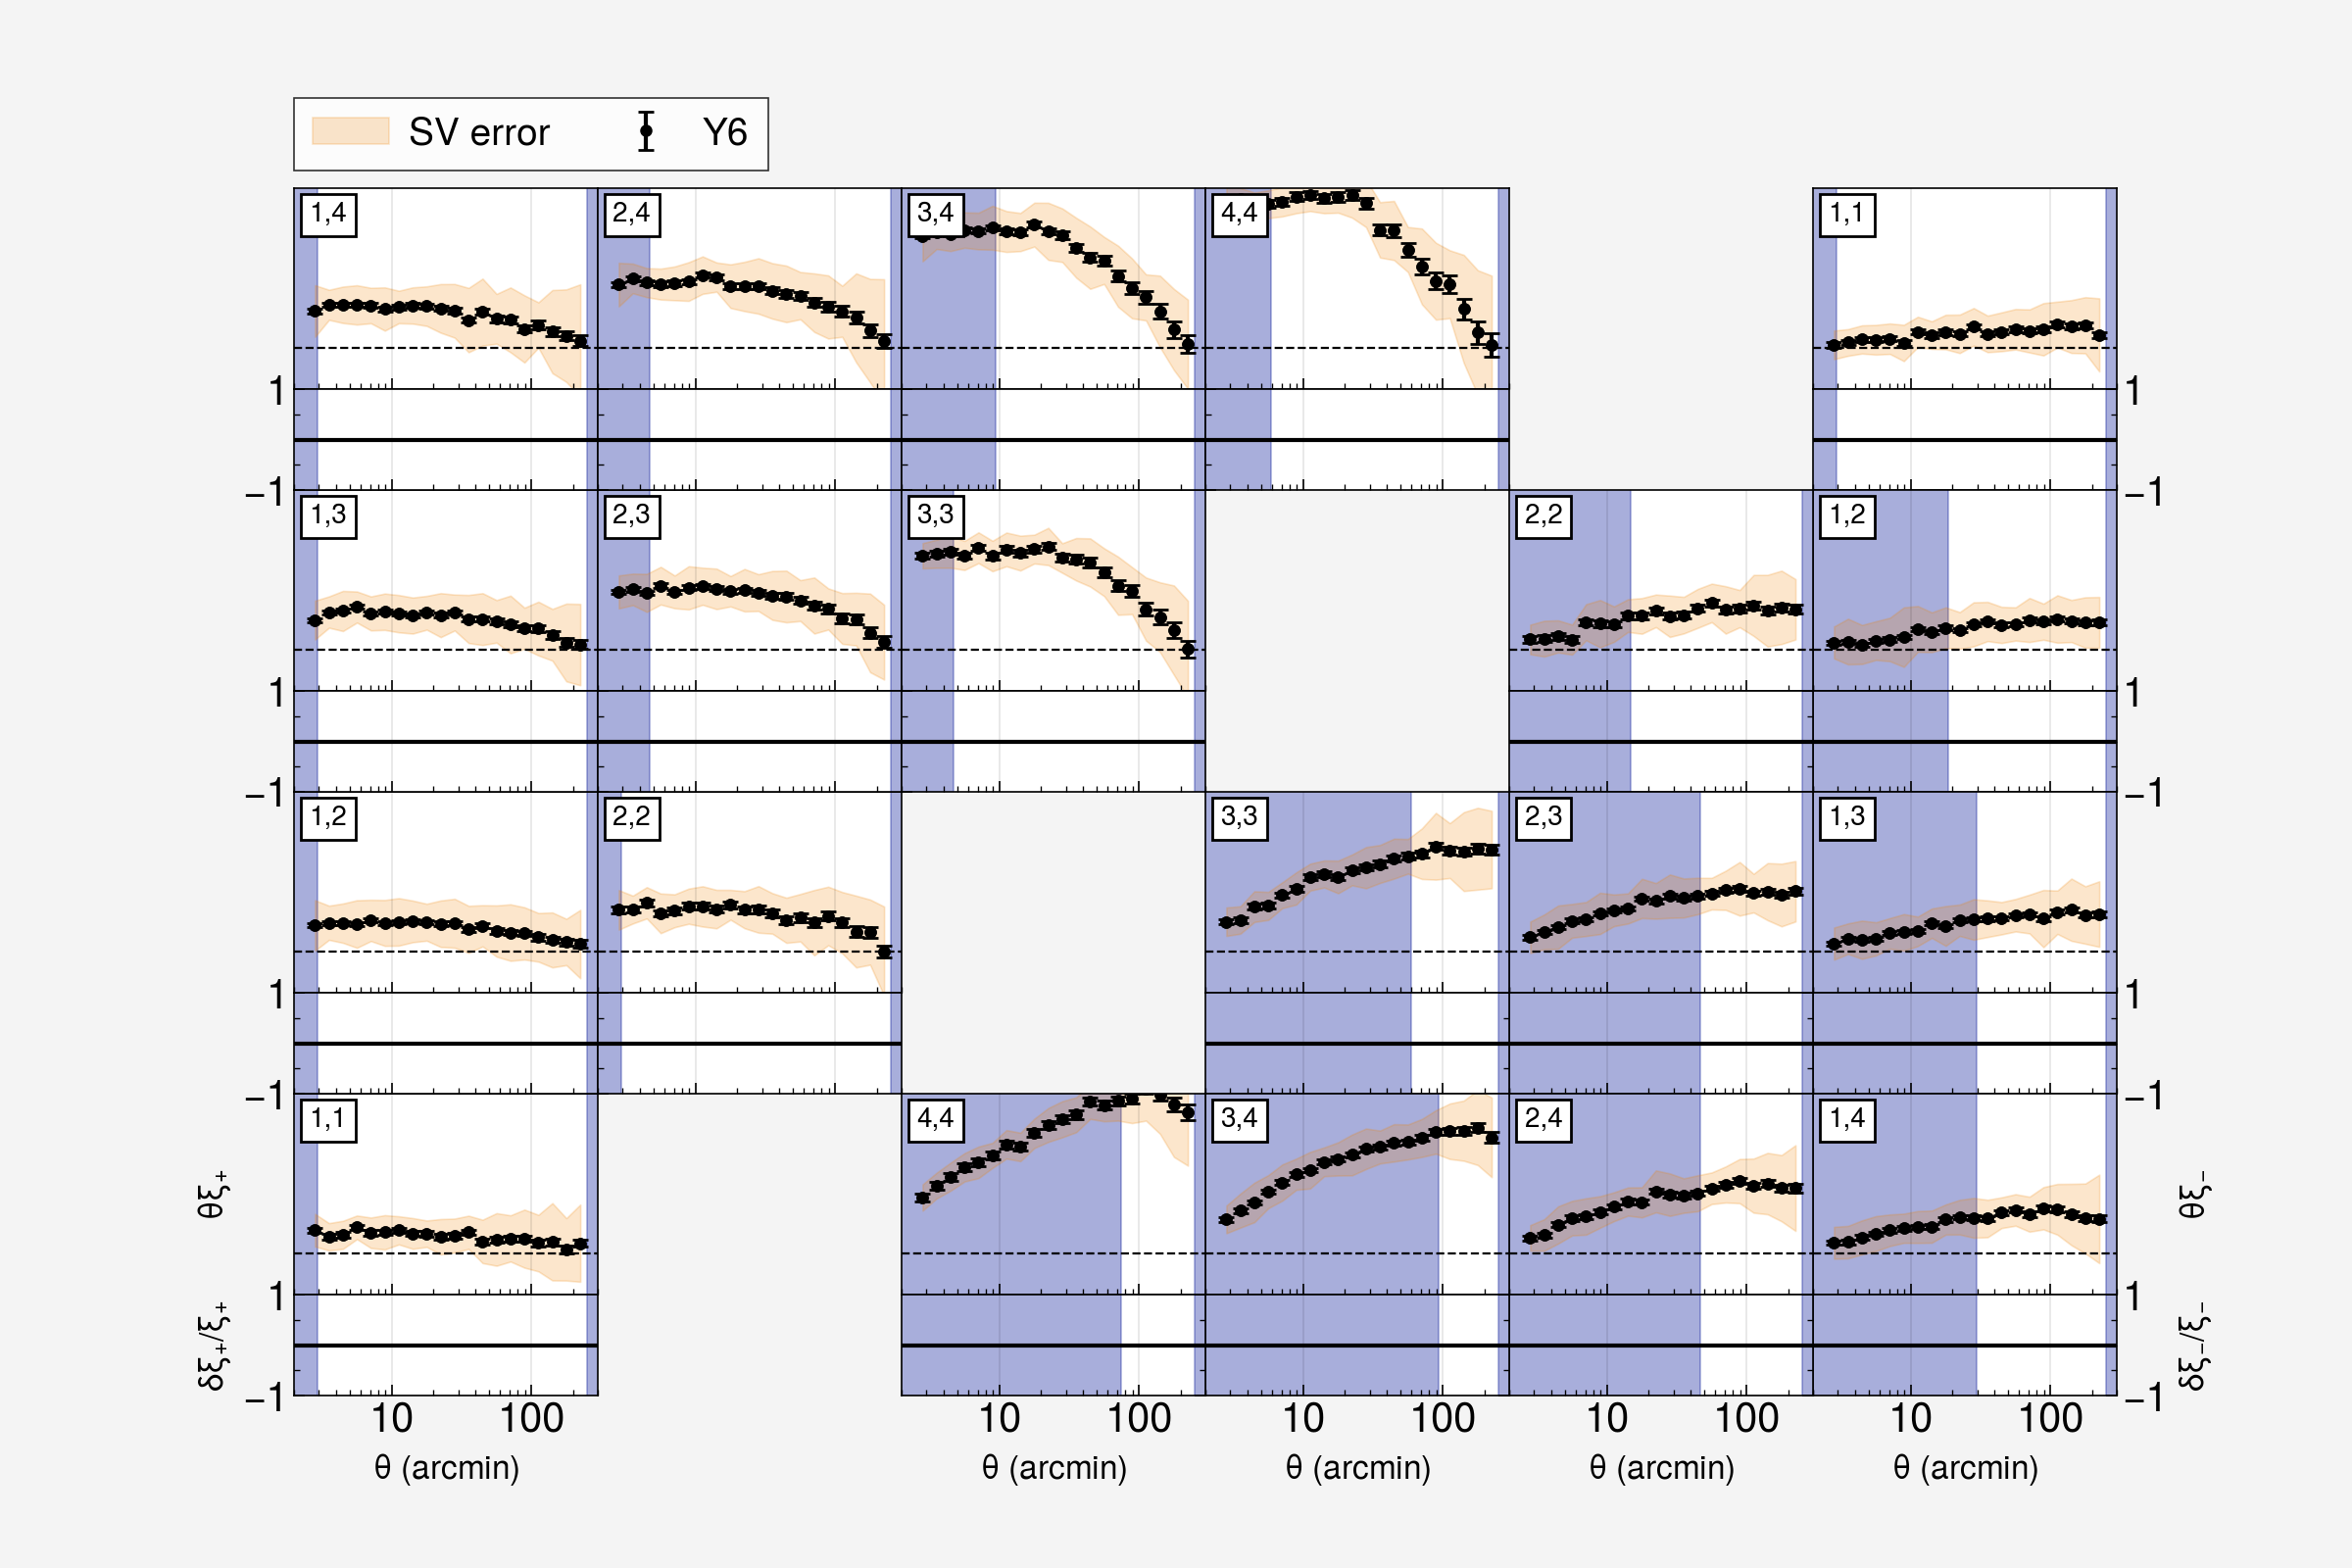

In [37]:
infile_sv = '/global/cfs/cdirs/des/myamamot/y6-cosmicshear/sv/2pt_sv2.fits'
infile_mdet = '/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/measurements/bins0.1/y6_mastermdetV6_UNBLINDED_BLINDED.fits'
scfile = '/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/scale_cuts/scales_1x2pt_chi2_3.50_v5.ini'
savedir = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER/'

import proplot as pplt
matplotlib.rcParams.update({'font.size': 15, 'legend.fontsize':'small', 'lines.markersize': 7, 'axes.labelsize': 12, "text.usetex": False})#, "font.family": "serif", "font.serif": ["Times New Roman"]})
plt.figure(figsize=(12,8))

fits   = infile_mdet
svfits = infile_sv

xip_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xip')
xim_   = tp.TwoPointFile.from_fits(fits).get_spectrum('xim')
sv_xip  = tp.TwoPointFile.from_fits(svfits).get_spectrum('xip')
sv_xim  = tp.TwoPointFile.from_fits(svfits).get_spectrum('xim')
pairs  = xip_.bin_pairs
rowcols = np.max(xip_.bin2)
#print(rowcols)

nbins = 20
for k,(i,j) in enumerate(pairs):
    theta  = xip_.get_pair(i,j)[0][:nbins]
    xip    = xip_.get_pair(i,j)[1][:nbins]
    xim    = xim_.get_pair(i,j)[1][:nbins]
    xiperr = xip_.get_error(i,j)[:nbins]
    ximerr = xim_.get_error(i,j)[:nbins]
    
    svxip    = sv_xip.get_pair(i,j)[1]
    svxim    = sv_xim.get_pair(i,j)[1]
    svxiperror = sv_xip.get_error(i,j)
    svximerror = sv_xim.get_error(i,j)

    plot_panel_res('xip',i,j,rowcols,rowcols,theta,xip,xiperr,svxip,svxiperror,0,notomo=False)
    plot_panel_res('xim',i,j,rowcols,rowcols,theta,xim,ximerr,svxim,svximerror,0,notomo=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0)
plt.savefig(savedir+'xipm+mdetV6MASTER_blinded_SV.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Baryons (max, min, scale cuts)

In [36]:
path_dv = '/pscratch/sd/m/myamamot/y6-3x2pt-methods/cosmosis/data_vectors/'
path_save = '/pscratch/sd/m/myamamot/des-y6-analysis/cosmicshear/v6_UNBLINDED_MASTER'

xip 1 1
xip 1 1
yes!
Abc
yes!
yes!
yes!
yes!
yes!
yes!
xim 1 4
xim 1 4
yes!
xim 2 4
xim 2 4
xim 3 4
xim 3 4
here
xim 4 4
xim 4 4


<ipython-input-45-f44880493969>:41: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


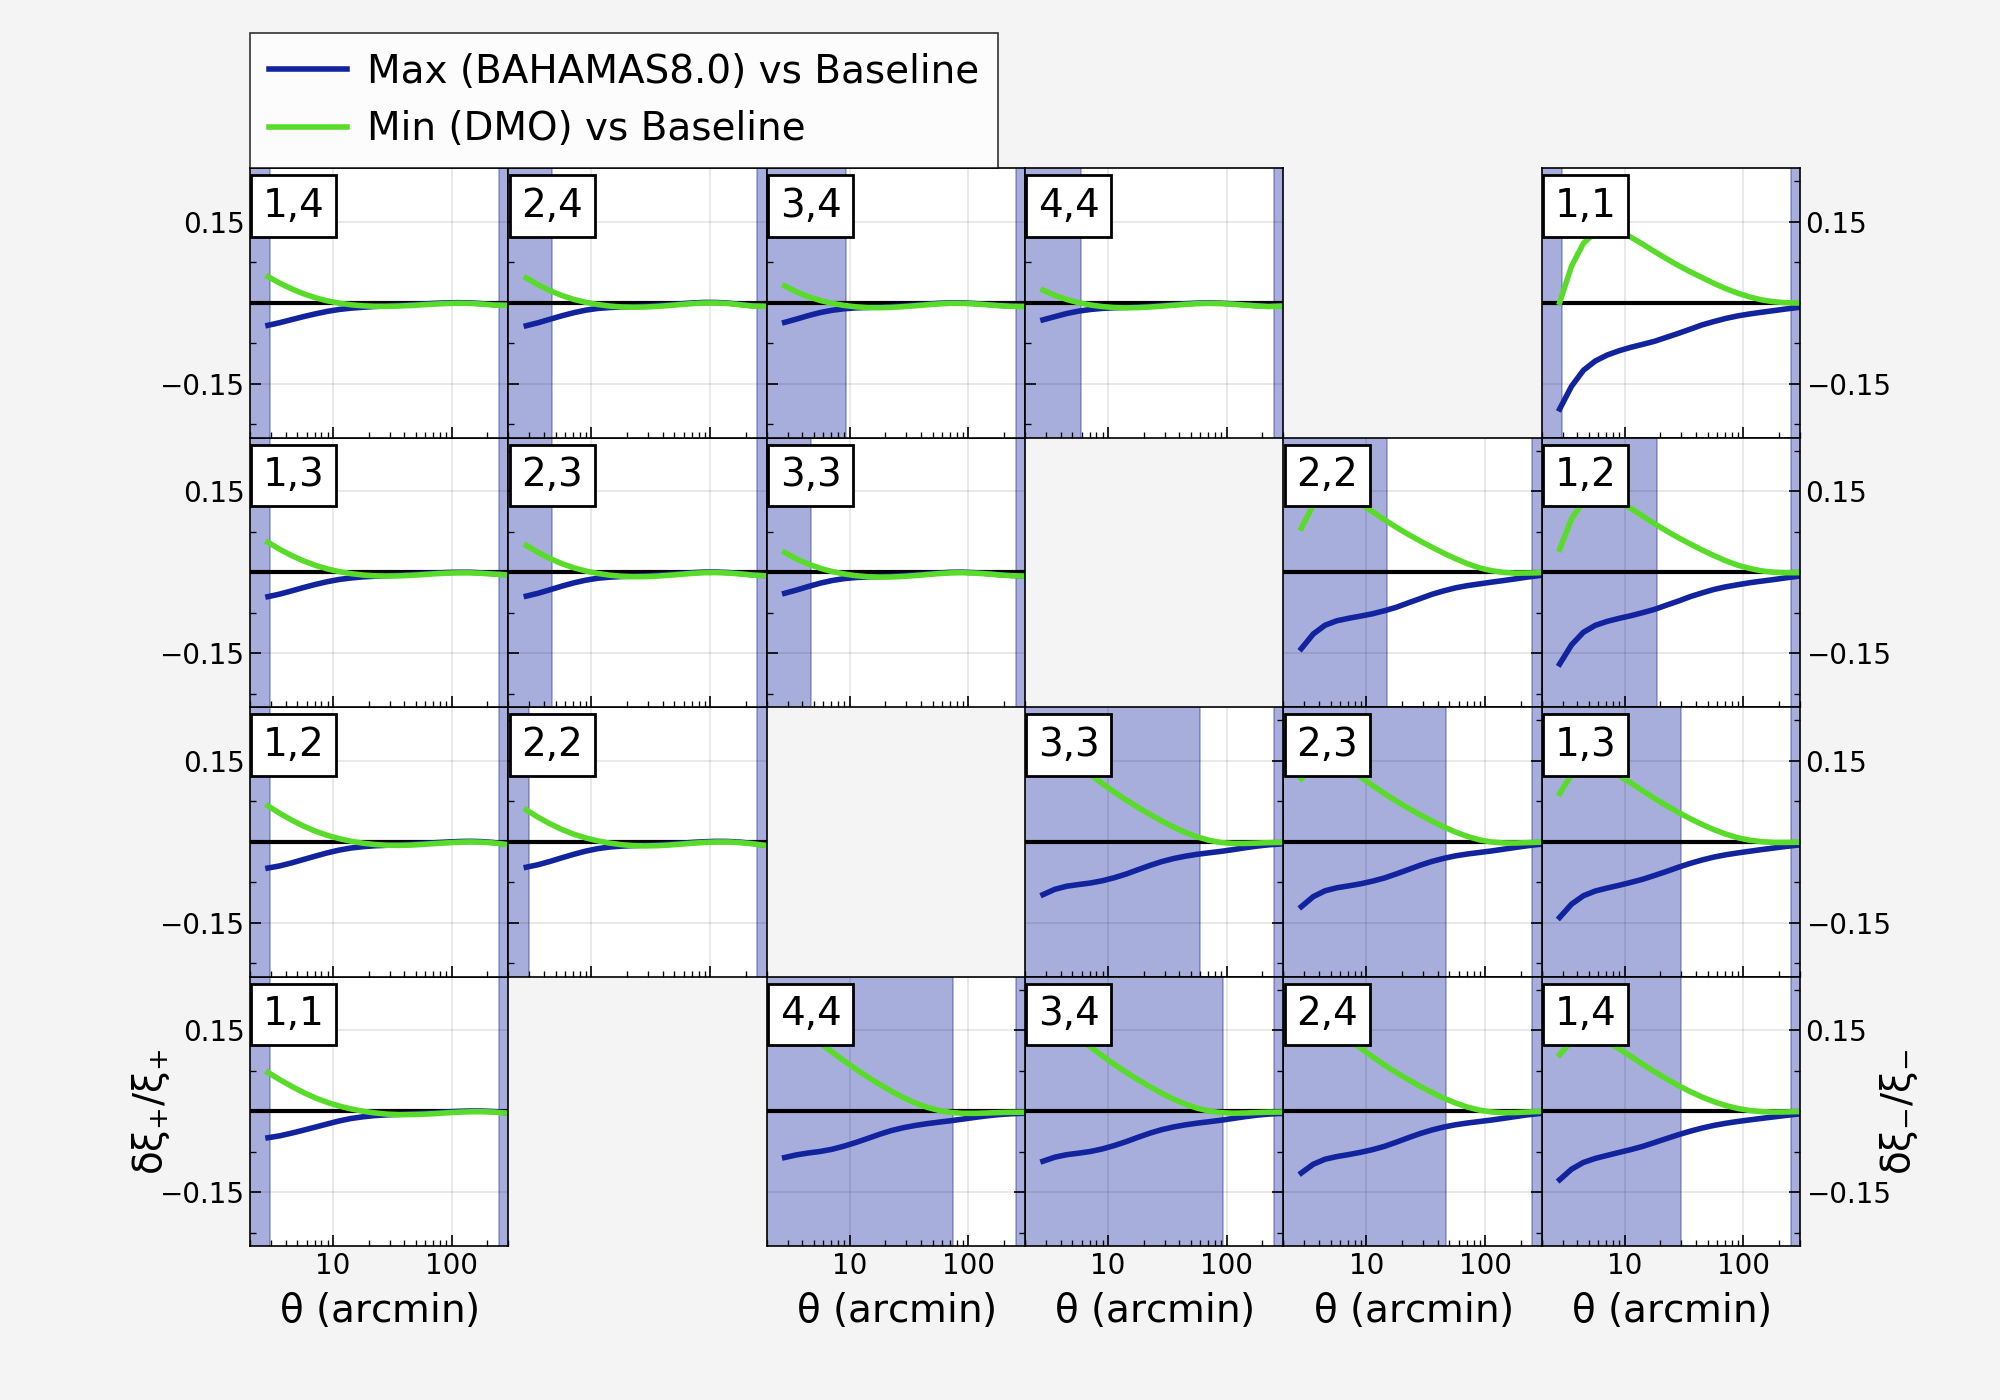

In [45]:
#PLOT DATA VECTOR
import proplot as pplt
plt.figure(figsize=(10,7))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 10,
    "font.serif": ["Times New Roman"],
})

scfile    =  os.path.join(path_dv, '../scale_cuts/scales_1x2pt_chi2_3.50_v5.ini')
maxfits   =  os.path.join(path_dv, 'sim_y6_max_contaminated_v5.fits')
minfits   =  os.path.join(path_dv, 'sim_y6_min_contaminated_v5.fits')
tfits     =  os.path.join(path_dv, 'sim_y6_baseline_v5.fits')

xip_max_   = tp.TwoPointFile.from_fits(maxfits).get_spectrum('xip')
xim_max_   = tp.TwoPointFile.from_fits(maxfits).get_spectrum('xim')
xip_min_   = tp.TwoPointFile.from_fits(minfits).get_spectrum('xip')
xim_min_   = tp.TwoPointFile.from_fits(minfits).get_spectrum('xim')
txip_   = tp.TwoPointFile.from_fits(tfits).get_spectrum('xip')
txim_   = tp.TwoPointFile.from_fits(tfits).get_spectrum('xim')
pairs   = xip_max_.bin_pairs
rowcols = np.max(xip_max_.bin2)
#print(rowcols)

colors = ['#b44c97', '#016e51']
for k,(i,j) in enumerate(pairs):
    theta  = xip_max_.get_pair(i,j)[0]
    xip_max    = xip_max_.get_pair(i,j)[1] 
    xim_max    = xim_max_.get_pair(i,j)[1] 
    xip_min    = xip_min_.get_pair(i,j)[1] 
    xim_min    = xim_min_.get_pair(i,j)[1] 
    
    xiperr = txip_.get_error(i,j)
    ximerr = txim_.get_error(i,j)
    txip    = txip_.get_pair(i,j)[1]
    txim    = txim_.get_pair(i,j)[1]

    plot_simpanel('xip',i,j,rowcols,rowcols,theta,xip_max,xip_min,xiperr,theta,txip,notomo=False)
    plot_simpanel('xim',i,j,rowcols,rowcols,theta,xim_max,xim_min,ximerr,theta,txim,notomo=False)
plt.tight_layout()
plt.subplots_adjust(hspace=0,wspace=0)
# plt.savefig(savedir+'additivebias_DVcomp.pdf', dpi=150,bbox_inches='tight')
plt.show()
plt.close()

# Code comparison

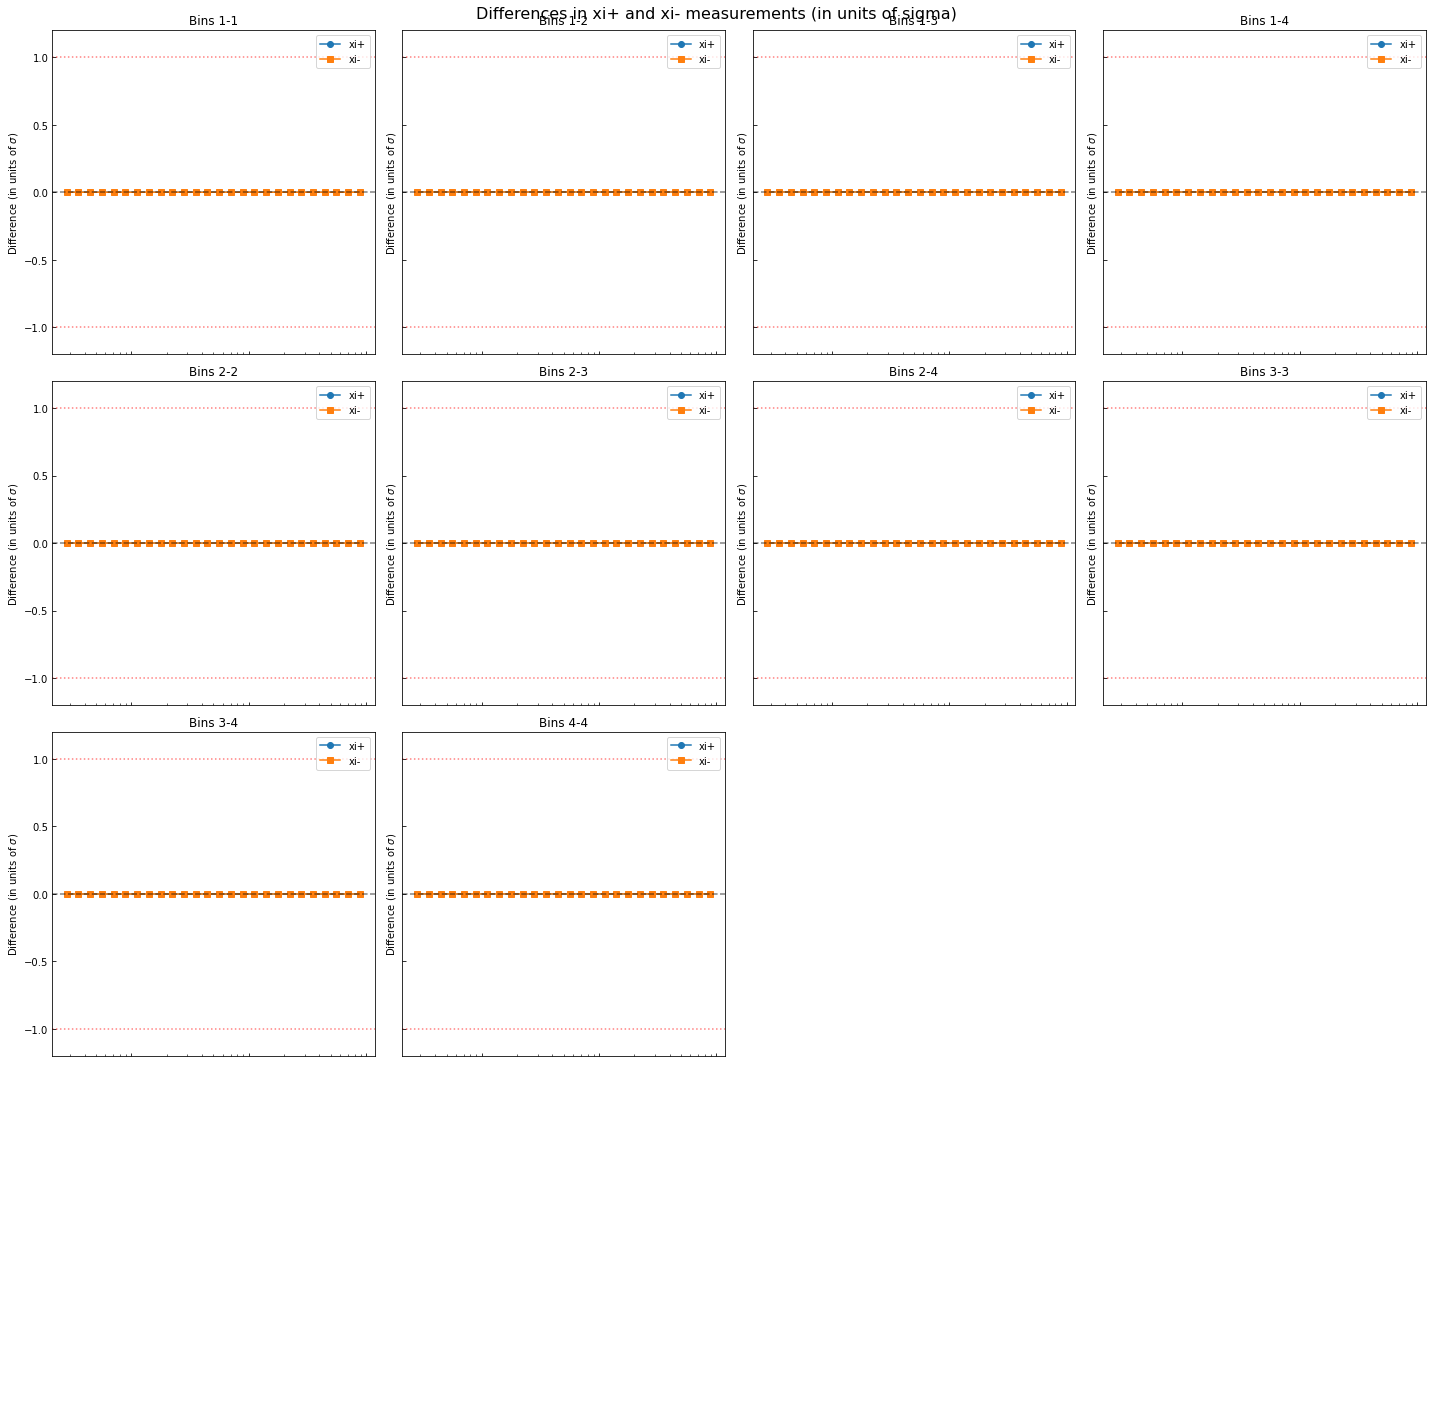

In [3]:
import twopoint
import matplotlib.pyplot as plt
import numpy as np

def compare_xip_xim(filename1, filename2, output_filename):
    # Load the two twopoint files
    T1 = twopoint.TwoPointFile.from_fits(filename1 + '.fits')
    T2 = twopoint.TwoPointFile.from_fits(filename2 + '.fits')
    # Extract the xip and xim spectra
    xip_judit = T1.spectra[0]
    xip_masa = T2.spectra[0]
    xim_judit = T1.spectra[1]
    xim_masa = T2.spectra[1]

    # Set up the plot for differences
    fig2, axes2 = plt.subplots(4, 4, figsize=(20, 20), sharex=True, sharey=True)
    fig2.suptitle('Differences in xi+ and xi- measurements (in units of sigma)', fontsize=16)
    axes2_flat = axes2.flatten()

    # Plot each bin combination
    for i, ax2 in enumerate(axes2_flat):
        if i < len(xip_judit.bin_pairs):
            bin1, bin2 = xip_judit.bin_pairs[i]
            
            # Get data for Judit's measurement
            theta_judit, xip_judit_values = xip_judit.get_pair(bin1, bin2)
            xip_judit_errors = xip_judit.get_error(bin1, bin2)
            _, xim_judit_values = xim_judit.get_pair(bin1, bin2)
            xim_judit_errors = xim_judit.get_error(bin1, bin2)
            
            # Get data for Masa's measurement
            theta_masa, xip_masa_values = xip_masa.get_pair(bin1, bin2)
            xip_masa_errors = xip_masa.get_error(bin1, bin2)
            _, xim_masa_values = xim_masa.get_pair(bin1, bin2)
            xim_masa_errors = xim_masa.get_error(bin1, bin2)
            
            # Calculate differences divided by sigma
            diff_xip = xip_masa_values - xip_judit_values
            diff_xim = xim_masa_values - xim_judit_values
            diff_sigma_xip = diff_xip / xip_judit_errors
            diff_sigma_xim = diff_xim / xim_judit_errors
            
            # Plot differences divided by sigma
            ax2.plot(theta_judit, diff_sigma_xip, 'o-', label='xi+')
            ax2.plot(theta_judit, diff_sigma_xim, 's-', label='xi-')
            ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
            ax2.axhline(y=1, color='r', linestyle=':', alpha=0.5)
            ax2.axhline(y=-1, color='r', linestyle=':', alpha=0.5)
            
            # Set scales and labels
            ax2.set_xscale('log')
            ax2.set_title(f'Bins {bin1}-{bin2}')
            ax2.legend()
            
            ax2.set_ylabel('Difference (in units of $\sigma$)')
            ax2.set_ylim(-1.2, 1.2)  # Adjust as needed
            
            if i >= 12:  # Only set xlabel for bottom row
                ax2.set_xlabel(r'$\theta$ (arcmin)')
        else:
            ax2.axis('off')

    plt.tight_layout()
    plt.show()
    # fig2.savefig(output_filename + '_diff_sigma.png')

# Usage
filename1 = '/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/measurements/3x2pt_UNBLINDED'
filename2 = '/global/cfs/cdirs/des/myamamot/y6-cosmicshear/mdet/measurements/y6_mastermdetV6_UNBLINDED'
compare_xip_xim(filename1, filename2, 'plots/cosmic_shear_test')